# Linear regression 
In this lab we train a Linear regressor with synthetic data for a regression problem (prediction of a real number). Given the "Time" feature, and a training set where the independent variable is the time, and the dependent variable is the average packet size. We want to predict the packet size to spot anomalies in the network traffic.

In [10]:
# Author: Roberto Doriguzzi-Corin
# Project: Course on Network Intrusion and Anomaly Detection with Machine Learning
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#   http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Import necessary libraries
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

OUTPUT_FILE = "./reg_tree"

# Generate some sample data (a sin function with some random noise)
np.random.seed(0)
m = 100 
X_train = 6 * np.random.rand(m, 1) - 3 
y_train = 0.5 * X_train**2 + X_train + 80 + 0.5*np.random.randn(m, 1)

# Fit a linear regressor
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Resulting curve: " + str(lr.intercept_[0]) + " + " + str(lr.coef_[0][0]) + "*Time") 

Resulting curve: 81.58780963928359 + 0.89094771400101*Time


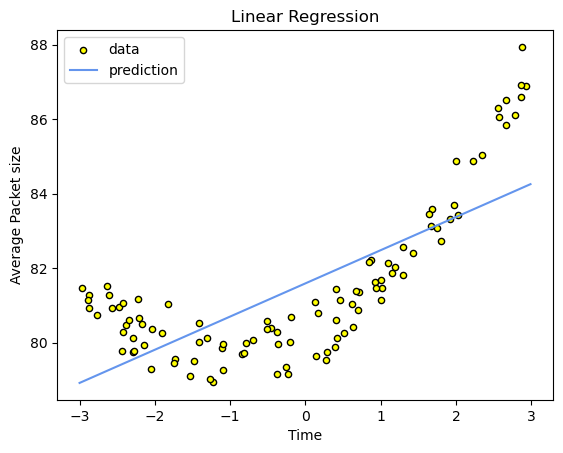

MSE measured on the benign training set:  1.9323011902022342


In [11]:
# Predictions (numbers from 0 to 5 with increment 0.01)
X_plot = np.arange(-3, 3, 0.01)[:, np.newaxis]
y_pred = lr.predict(X_plot)

# Plot the results
plt.figure()
plt.scatter(X_train, y_train, s=20, edgecolor="black", c="yellow", label="data")
plt.plot(X_plot, y_pred, color="cornflowerblue", label="prediction")
plt.xlabel("Time")
plt.ylabel("Average Packet size")
plt.title("Linear Regression")
plt.legend()
plt.show()

# Error on the training set
y_pred = lr.predict(X_train)
mse = mean_squared_error(y_train,y_pred)
print("MSE measured on the benign training set: ", mse)

# Linear regression with polynomial features
You can use a linear model to fit nonlinear data. A simple way to do this is to add powers of each feature as new features, then train a linear model on this extended set of features. This technique is called Polynomial Regression. 

In [12]:
# X_poly now contains the original feature of X plus the square of this feature
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X_train)

lr = LinearRegression() 
lr.fit(X_poly, y_train)
print("Resulting curve: " + str(lr.intercept_[0]) + " + " + str(lr.coef_[0][0]) + "*Time" + " + " + str(lr.coef_[0][1]) + "*Time^2") 

[80.17025038] [[0.98953276 0.47489412]]


Resulting curve: 80.17025037813143 + 0.9895327604977373*Time + 0.4748941150004222*Time^2


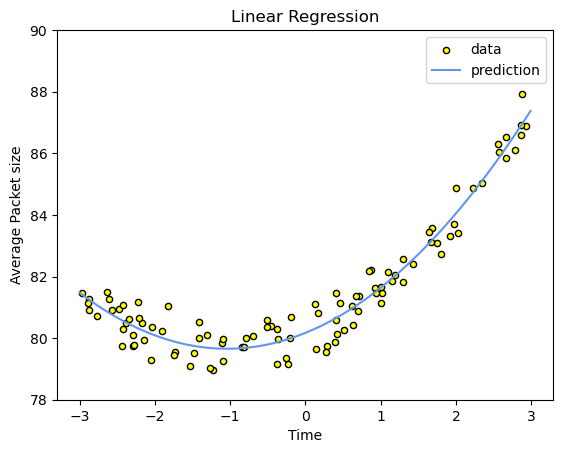

MSE measured on the benign training set:  0.24338941808535566


In [13]:
# Predictions (numbers from 0 to 5 with increment 0.01)
X_plot = np.arange(-3, 3, 0.01)[:, np.newaxis]
X_plot_poly = poly_features.fit_transform(X_plot)
y_pred = lr.predict(X_plot_poly)

# Plot the results
plt.figure()
plt.scatter(X_train, y_train, s=20, edgecolor="black", c="yellow", label="data")
plt.plot(X_plot, y_pred, color="cornflowerblue", label="prediction")
plt.xlabel("Time")
plt.ylabel("Average Packet size")
plt.ylim([78, 90])
plt.title("Linear Regression")
plt.legend()
plt.show()

# Error on the training set
y_pred = lr.predict(X_poly)
mse = mean_squared_error(y_train,y_pred)
print("MSE measured on the benign training set: ", mse)